In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import kagglehub

In [2]:
print("Downloading TikTok Dances Dataset...")
path = kagglehub.dataset_download("tapakah68/segmentation-full-body-tiktok-dancing-dataset")
base_dir = os.path.join(path, "segmentation_full_body_tik_tok_2615_img")

100%|██████████| 1.82G/1.82G [00:47<00:00, 41.5MB/s]

Extracting files...


In [3]:
# Handle nested directory structure if present
if "segmentation_full_body_tik_tok_2615_img" in os.listdir(base_dir):
    base_dir = os.path.join(base_dir, "segmentation_full_body_tik_tok_2615_img")

image_dir = os.path.join(base_dir, "images")
mask_dir = os.path.join(base_dir, "masks")

print(f"Dataset ready at: {base_dir}")

Dataset ready at: /root/.cache/kagglehub/datasets/tapakah68/segmentation-full-body-tiktok-dancing-dataset/versions/2/segmentation_full_body_tik_tok_2615_img/segmentation_full_body_tik_tok_2615_img


In [4]:
class PersonDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir))
        self.img_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        image = Image.open(os.path.join(self.image_dir, img_name)).convert("RGB")
        mask = Image.open(os.path.join(self.mask_dir, img_name)).convert("L")

        image = TF.resize(image, (128, 128))
        mask = TF.resize(mask, (128, 128))

        image_tensor = TF.to_tensor(image)
        mask_tensor = TF.to_tensor(mask)

        # Apply symmetrical horizontal flip for data augmentation
        if random.random() > 0.5:
            image_tensor = TF.hflip(image_tensor)
            mask_tensor = TF.hflip(mask_tensor)

        image_tensor = self.img_norm(image_tensor)
        mask_tensor = (mask_tensor > 0).float()

        return image_tensor, mask_tensor

In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up_conv1 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up_conv2 = DoubleConv(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up_conv3 = DoubleConv(128, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(F.max_pool2d(x1, 2))
        x3 = self.down3(F.max_pool2d(x2, 2))
        x4 = self.down4(F.max_pool2d(x3, 2))

        x = self.up1(x4)
        x = torch.cat([x, x3], dim=1)
        x = self.up_conv1(x)

        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up_conv2(x)

        x = self.up3(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up_conv3(x)

        return self.out_conv(x)

In [6]:
def combined_loss(pred, target):
    bce = nn.BCEWithLogitsLoss()(pred, target)
    pred_sig = torch.sigmoid(pred)
    smooth = 1e-6
    inter = (pred_sig * target).sum()
    dice = 1 - (2. * inter + smooth) / (pred_sig.sum() + target.sum() + smooth)
    return bce + dice

In [7]:
def calculate_metrics(pred, target):
    pred_mask = (torch.sigmoid(pred) > 0.5).float().view(-1)
    target_flat = target.view(-1)

    intersection = (pred_mask * target_flat).sum()
    union = pred_mask.sum() + target_flat.sum() - intersection

    iou = (intersection + 1e-6) / (union + 1e-6)
    dice = (2. * intersection + 1e-6) / (pred_mask.sum() + target_flat.sum() + 1e-6)
    return iou.item(), dice.item()

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

dataset = PersonDataset(image_dir, mask_dir)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

dataset = PersonDataset(image_dir, mask_dir)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

epochs = 30
print(f"Starting training on {device} for {epochs} epochs...")

Starting training on cuda for 30 epochs...


In [10]:
train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for imgs, msks in train_loader:
        imgs, msks = imgs.to(device), msks.to(device)
        out = model(imgs)
        loss = combined_loss(out, msks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f}")
    scheduler.step(avg_loss)

Epoch [1/30] | Loss: 1.0354
Epoch [2/30] | Loss: 0.7971
Epoch [3/30] | Loss: 0.6718
Epoch [4/30] | Loss: 0.5664
Epoch [5/30] | Loss: 0.4760
Epoch [6/30] | Loss: 0.4044
Epoch [7/30] | Loss: 0.3444
Epoch [8/30] | Loss: 0.2943
Epoch [9/30] | Loss: 0.2604
Epoch [10/30] | Loss: 0.2228
Epoch [11/30] | Loss: 0.1980
Epoch [12/30] | Loss: 0.1724
Epoch [13/30] | Loss: 0.1594
Epoch [14/30] | Loss: 0.1485
Epoch [15/30] | Loss: 0.1323
Epoch [16/30] | Loss: 0.1248
Epoch [17/30] | Loss: 0.1107
Epoch [18/30] | Loss: 0.1080
Epoch [19/30] | Loss: 0.0952
Epoch [20/30] | Loss: 0.1015
Epoch [21/30] | Loss: 0.0866
Epoch [22/30] | Loss: 0.0803
Epoch [23/30] | Loss: 0.0748
Epoch [24/30] | Loss: 0.0707
Epoch [25/30] | Loss: 0.0657
Epoch [26/30] | Loss: 0.0622
Epoch [27/30] | Loss: 0.0598
Epoch [28/30] | Loss: 0.0933
Epoch [29/30] | Loss: 0.0702
Epoch [30/30] | Loss: 0.0581


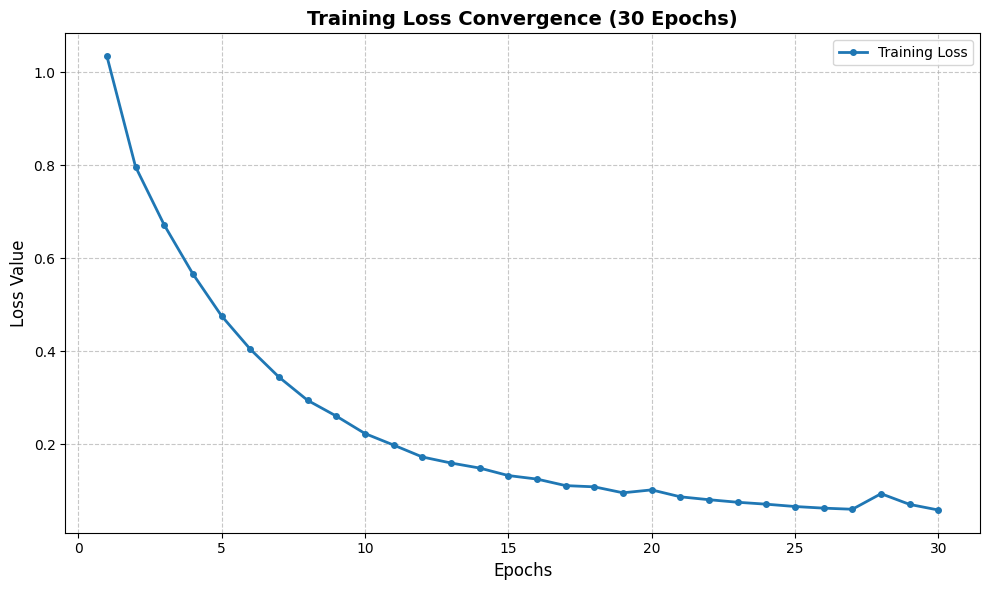

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, marker='o', markersize=4, color='#1f77b4', linewidth=2, label='Training Loss')

plt.title('Training Loss Convergence (30 Epochs)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.savefig('loss_curve_30_epochs.png', dpi=300)
plt.show()

In [12]:
torch.save(model.state_dict(), "unet_human_segmentation.pth")
print("Model saved successfully!")

Model saved successfully!


In [13]:
model.eval()
total_iou, total_dice = 0, 0

with torch.no_grad():
    for imgs, msks in val_loader:
        imgs, msks = imgs.to(device), msks.to(device)
        preds = model(imgs)
        iou, dice = calculate_metrics(preds, msks)
        total_iou += iou
        total_dice += dice

print(f"\nValidation IoU: {total_iou / len(val_loader):.4f}")
print(f"Validation Dice Score: {total_dice / len(val_loader):.4f}")


Validation IoU: 0.9061
Validation Dice Score: 0.9506


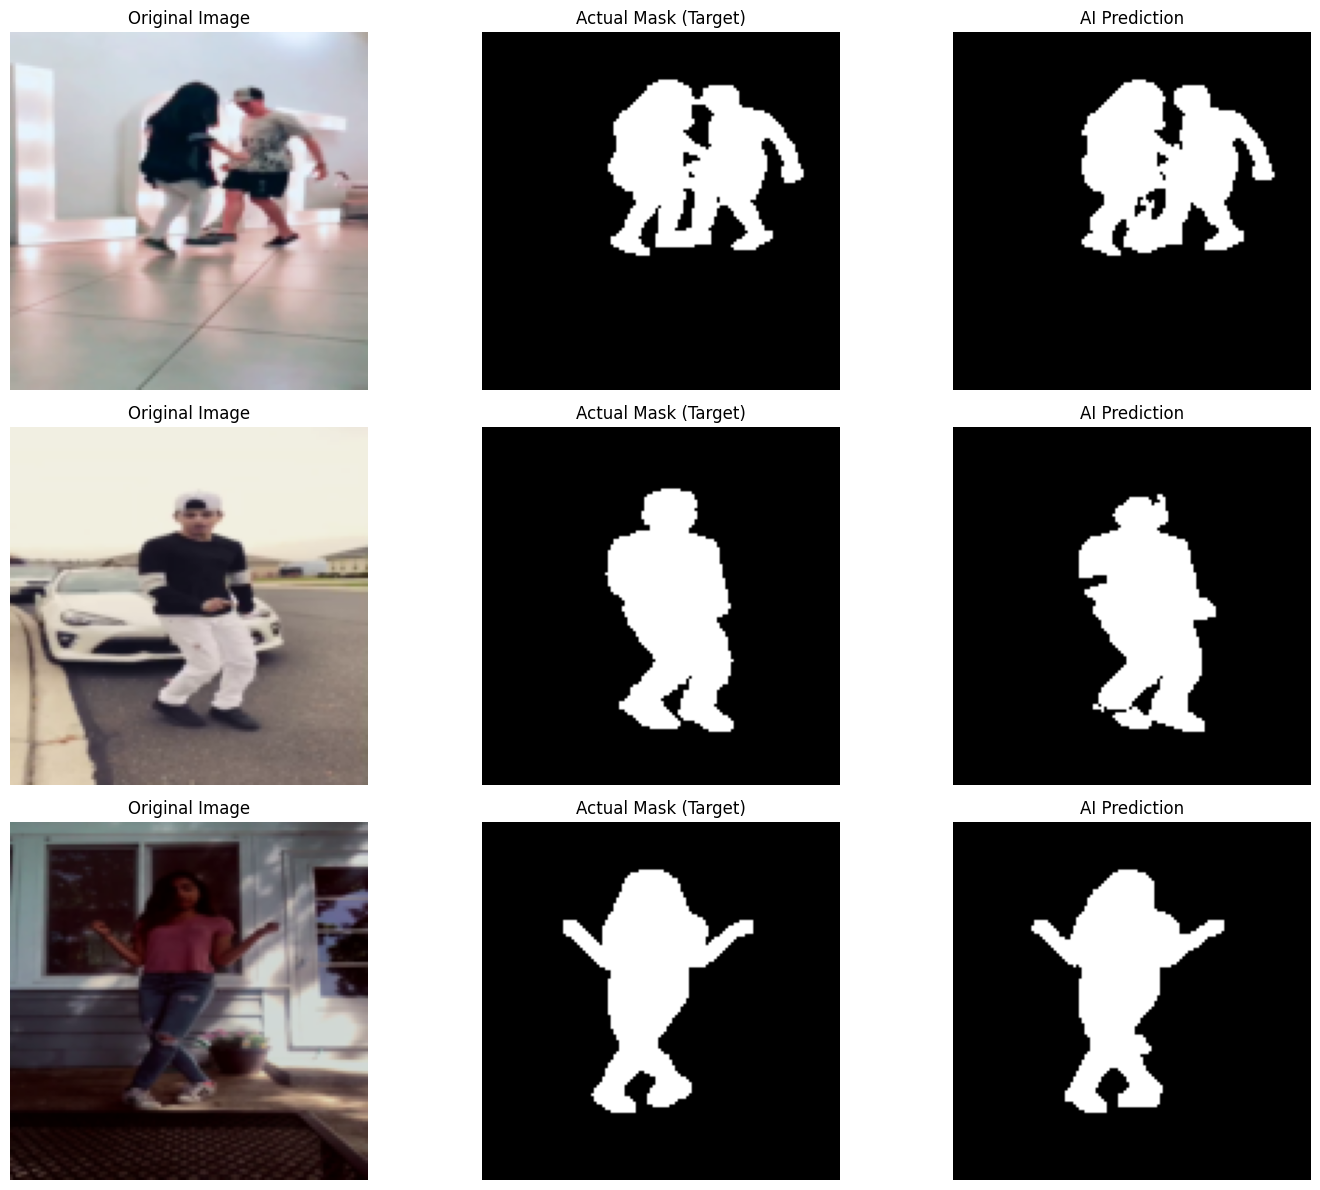

In [14]:
model.eval()
plt.figure(figsize=(15, 12))

sample_indices = random.sample(range(len(val_ds)), 3)

for i, idx in enumerate(sample_indices):
    img, msk = val_ds[idx]

    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))

    pred_prob = torch.sigmoid(pred[0][0].cpu())
    pred_mask = (pred_prob > 0.5).float()

    img_show = img.permute(1, 2, 0).numpy()
    img_show = np.clip(img_show * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)

    plt.subplot(3, 3, i*3 + 1)
    plt.imshow(img_show)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(3, 3, i*3 + 2)
    plt.imshow(msk.squeeze(), cmap="gray")
    plt.title("Actual Mask (Target)")
    plt.axis("off")

    plt.subplot(3, 3, i*3 + 3)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("AI Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
from PIL import Image
from google.colab import files

In [32]:
print("Upload image (format .jpg / .png):")
uploaded = files.upload()

Upload image (format .jpg / .png):


Saving test 3.png to test 3.png


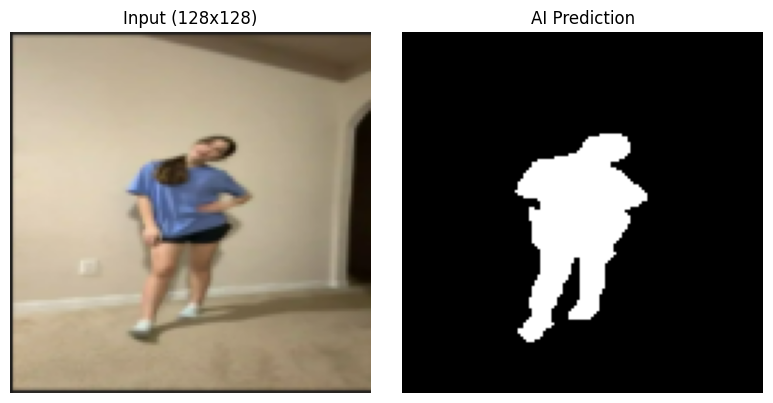

In [33]:
if uploaded:
    file_name = list(uploaded.keys())[0]

    img = Image.open(file_name).convert("RGB")
    img_resized = TF.resize(img, (128, 128))

    img_tensor = TF.to_tensor(img_resized)
    img_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    img_tensor_norm = img_norm(img_tensor).unsqueeze(0).to(device)


    model.eval()
    with torch.no_grad():
        pred = model(img_tensor_norm)
        pred_mask = (torch.sigmoid(pred[0][0].cpu()) > 0.5).float()

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_resized)
    plt.title("Input (128x128)")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("AI Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.show()